# 4 · Finite differences vs finite volumes

`bandsolver` does not discretize anything itself. It solves the equations you give it, as long as each equation at node $j$ involves only nodes $j-1$, $j$ and $j+1$ (plus one extra node at each end through the $\mathsf X,\mathsf Y$ blocks). Both classic discretization families produce exactly that structure:

| | **finite differences (FD)** | **finite volumes (FV)** |
|---|---|---|
| unknowns | point values $c_j$ at nodes | averages over control volumes around nodes |
| what is approximated | the *differential equation*, e.g. $\partial_x^2 c \approx (c_{j+1}-2c_j+c_{j-1})/h^2$ | the *integral balance*: accumulation $=$ flux in $-$ flux out |
| strengths | simple; easy high-order stencils and one-sided boundaries (via $\mathsf X,\mathsf Y$) | conservation built in; natural at material interfaces and on non-uniform meshes |

In this notebook we solve **the same battery-relevant problem both ways, with the same solver**, and see why battery models are almost always written in finite volumes. We also see when finite differences are perfectly fine.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bandsolver as bs

# Plot style: categorical colours in fixed order, an ordinal blue ramp for time series,
# neutral ink for text, thin marks and a recessive grid.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]   # light -> dark
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.markersize": 6, "legend.frameon": False,
    "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11,
})
print("bandsolver", bs.__version__, "| backends:", bs.BACKENDS)

bandsolver 0.1.1 | backends: ('cpp', 'fortran')


## 1. The problem: diffusion through a porous electrode and a separator

The electrolyte in a battery fills the pores of the electrode ($0<x<L_e$) and of the separator ($L_e<x<L$). The two layers have different porosities $\varepsilon$, and hence different effective diffusivities. The Bruggeman relation is $D_{\text{eff}} = D\,\varepsilon^{1.5}$. The salt balance is

$$
\varepsilon(x)\,\frac{\partial c}{\partial t} = \frac{\partial}{\partial x}\!\left(D_{\text{eff}}(x)\,\frac{\partial c}{\partial x}\right),
\qquad
\varepsilon, D_{\text{eff}} = \begin{cases}\varepsilon_e,\ D\,\varepsilon_e^{1.5} & x < L_e \ (\text{electrode})\\ \varepsilon_s,\ D\,\varepsilon_s^{1.5} & x > L_e \ (\text{separator})\end{cases}
$$

At the interface, both the concentration and the **flux** are continuous:

$$
c(L_e^-) = c(L_e^+),\qquad D_e\,\partial_x c\,(L_e^-) = D_s\,\partial_x c\,(L_e^+).
$$

**Boundary conditions.** The ends are sealed: $\partial_x c = 0$ at $x=0$ and $x=L$. The electrolyte starts with a smooth concentration gradient, as a current pulse would leave it, and relaxes toward uniformity.

With sealed ends, no salt can enter or leave, so **the total amount of salt $\int_0^L \varepsilon\,c\,dx$ must stay constant**. A battery model that violates this slowly creates or destroys lithium.

In [2]:
D = 2.0e-10                          # free-electrolyte diffusivity, m^2/s
Le, Ls = 70e-6, 25e-6                # electrode and separator thickness, m
L = Le + Ls
eps_e, eps_s = 0.3, 0.5              # porosities
De, Ds = D * eps_e**1.5, D * eps_s**1.5
c_init = lambda x: 1000.0 * (1 + 0.4 * np.cos(np.pi * x / L))   # mol/m^3
dt, t_end = 0.5, 100.0               # s
print(f"D_eff: electrode {De:.2e}, separator {Ds:.2e} m^2/s  (ratio {Ds / De:.2f})")
print(f"diffusion time L^2/D_eff ~ {L**2 / De:.0f} s; we simulate {t_end:g} s")

def uniform_mesh(nj):
    """Uniform mesh with a node exactly on the interface (requires (nj-1) % 19 == 0)."""
    assert (nj - 1) % 19 == 0
    return np.linspace(0, L, nj)

def amount(x, c):
    """Total salt, integral of eps*c dx, exact for piecewise-linear c (trapezoid per interval)."""
    xm = 0.5 * (x[:-1] + x[1:])
    return np.sum(np.where(xm < Le, eps_e, eps_s) * np.diff(x) * 0.5 * (c[:-1] + c[1:]))

D_eff: electrode 3.29e-11, separator 7.07e-11 m^2/s  (ratio 2.15)
diffusion time L^2/D_eff ~ 275 s; we simulate 100 s


## 2. Finite differences

### 2a. The "natural" nodal scheme

Dividing by $\varepsilon$ in each region gives $\partial_t c = (D_{\text{eff}}/\varepsilon)\,\partial_x^2 c$. Discretize it node by node with implicit Euler, using ghost points for the sealed ends:

$$
\frac{c_j - c_j^{\text{old}}}{\Delta t} - k_j\,\frac{c_{j+1} - 2c_j + c_{j-1}}{h^2} = 0,\qquad k_j = \frac{D_{\text{eff}}(x_j)}{\varepsilon(x_j)},
\qquad c_{-1} = c_1,\ c_{n_j} = c_{n_j-2}\ \ (\text{ghost points}).
$$

This looks reasonable, but it is **wrong** at the interface. Expanding the original operator gives $\partial_x(D\,\partial_x c) = D\,\partial_x^2 c + D'\,\partial_x c$. Because $D$ jumps, $D'$ is a delta function at $x = L_e$, and the nodal scheme simply drops it. The interface flux is never balanced.

### 2b. FD with an interface matching condition

The standard fix in finite differences is to replace the equation at the interface node by the **flux-continuity condition**, written with one-sided differences on each side:

$$
D_e\,\frac{c_j - c_{j-1}}{h} = D_s\,\frac{c_{j+1} - c_j}{h} \qquad (j = \text{interface node}).
$$

This is an algebraic row, which BAND handles without any special treatment. It is consistent, but the one-sided differences are only first-order accurate, and the interface node carries no storage term.

In [3]:
def fd_fill(x, c_old, match_interface):
    nj, h = x.size, x[1] - x[0]
    region_e = x < Le - 1e-12 * L
    k = np.where(region_e, De / eps_e, Ds / eps_s)
    ji = int(round(Le / h))                                     # interface node

    def fill(c):
        u = c[:, 0]
        lap = np.empty(nj)
        lap[1:-1] = (u[2:] - 2 * u[1:-1] + u[:-2]) / h**2
        lap[0], lap[-1] = 2 * (u[1] - u[0]) / h**2, 2 * (u[-2] - u[-1]) / h**2   # ghost points
        Fr = (u - c_old) / dt - k * lap
        A = np.zeros((nj, 1, 1)); B = np.zeros((nj, 1, 1)); Dk = np.zeros((nj, 1, 1))
        B[:, 0, 0] = 1 / dt + 2 * k / h**2
        A[1:, 0, 0], Dk[:-1, 0, 0] = -k[1:] / h**2, -k[:-1] / h**2
        Dk[0, 0, 0], A[-1, 0, 0] = -2 * k[0] / h**2, -2 * k[-1] / h**2
        if match_interface:                                     # flux continuity replaces the row
            Fr[ji] = De * (u[ji] - u[ji - 1]) / h - Ds * (u[ji + 1] - u[ji]) / h
            A[ji, 0, 0], B[ji, 0, 0], Dk[ji, 0, 0] = -De / h, (De + Ds) / h, -Ds / h
        return A, B, Dk, -Fr[:, None]
    return fill

## 3. Finite volumes

Integrate the balance over a control volume $[x_{j-\frac12}, x_{j+\frac12}]$ around node $j$:

$$
\underbrace{\left(\int \varepsilon\,dx\right)_j}_{\text{capacity } \mathcal C_j}\ \frac{c_j - c_j^{\text{old}}}{\Delta t} \;+\; N_{j+\frac12} - N_{j-\frac12} = 0,
\qquad N_{j+\frac12} = -D_{j+\frac12}\,\frac{c_{j+1}-c_j}{x_{j+1}-x_j}.
$$

Three properties make this the natural choice here:

- **Conservation is exact.** Every face flux leaves one volume and enters its neighbour, so summing all equations telescopes to $\frac{d}{dt}\sum_j \mathcal C_j c_j = (\text{boundary fluxes}) = 0$. This holds for any mesh and any time step.
- **Interfaces are easy.** With a node on the interface, every face lies inside one material, so $D_{j+\frac12}$ is unambiguous. The interface node's volume simply has capacity $\tfrac12(h_-\varepsilon_e + h_+\varepsilon_s)$. If a material boundary falls *inside* a cell, or $D$ varies continuously, use the harmonic mean $D_{j+\frac12} = \frac{2D_jD_{j+1}}{D_j+D_{j+1}}$, which is the value that makes the flux continuous across a jump.
- **Non-uniform meshes cost nothing.** The formulas above never assumed equal spacing.

In [4]:
def fv_fill(x, c_old):
    nj, h = x.size, np.diff(x)                                  # h may vary: any mesh works
    xm = 0.5 * (x[:-1] + x[1:])
    Df = np.where(xm < Le, De, Ds)                              # each face lies in one material
    eps_f = np.where(xm < Le, eps_e, eps_s)
    cap = np.zeros(nj)                                          # capacity = integral of eps over the volume
    cap[:-1] += eps_f * h / 2
    cap[1:] += eps_f * h / 2

    def fill(c):
        u = c[:, 0]
        N = -Df * np.diff(u) / h                                # face fluxes
        Fr = cap * (u - c_old) / dt
        Fr[:-1] += N; Fr[1:] -= N                               # out through the right face, in through the left
        A = np.zeros((nj, 1, 1)); B = np.zeros((nj, 1, 1)); Dk = np.zeros((nj, 1, 1))
        B[:, 0, 0] = cap / dt
        B[:-1, 0, 0] += Df / h; Dk[:-1, 0, 0] = -Df / h
        B[1:, 0, 0] += Df / h;  A[1:, 0, 0] = -Df / h
        return A, B, Dk, -Fr[:, None]                           # sealed ends: no boundary flux terms
    return fill

def simulate(method, x, snapshot_at=None, history=None):
    """March to t_end. Optionally store the profile at `snapshot_at` and the salt amount over time."""
    c = c_init(x)[:, None]
    snapshot = None
    for step in range(1, int(round(t_end / dt)) + 1):
        c_old = c[:, 0].copy()
        fill = fv_fill(x, c_old) if method == "FV" else fd_fill(x, c_old, method == "FD + interface matching")
        c = bs.newton(fill, c).c
        if history is not None:
            history.append(amount(x, c[:, 0]))
        if snapshot_at is not None and abs(step * dt - snapshot_at) < 1e-9:
            snapshot = c[:, 0].copy()
    return c[:, 0] if snapshot_at is None else (c[:, 0], snapshot)

## 4. Comparison

The reference is a very fine finite-volume solution (1,217 nodes) computed with the **same time step**. Comparing against it therefore isolates the *spatial* error of each scheme.

In [5]:
x_ref = uniform_mesh(19 * 64 + 1)
c_ref = simulate("FV", x_ref)
methods = ["FD (nodal)", "FD + interface matching", "FV"]
grids = [39, 77, 153, 305]
results = {m: [] for m in methods}
for m in methods:
    for nj in grids:
        x = uniform_mesh(nj)
        c = simulate(m, x)
        err = np.abs(c - np.interp(x, x_ref, c_ref)).max()
        drift = (amount(x, c) - amount(x, c_init(x))) / amount(x, c_init(x))
        results[m].append((nj, err, drift, x, c))

print(f"{'method':25s} {'nodes':>5s} {'max error (mol/m^3)':>20s} {'order':>6s} {'salt created/destroyed':>23s}")
for m in methods:
    prev = None
    for nj, err, drift, *_ in results[m]:
        order = f"{np.log2(prev / err):6.2f}" if prev else "     -"
        print(f"{m:25s} {nj:5d} {err:20.3e} {order} {drift:+23.2e}")
        prev = err

method                    nodes  max error (mol/m^3)  order  salt created/destroyed
FD (nodal)                   39            7.650e+01      -               +8.07e-02
FD (nodal)                   77            7.605e+01   0.01               +8.03e-02
FD (nodal)                  153            7.582e+01   0.00               +8.01e-02
FD (nodal)                  305            7.570e+01   0.00               +7.99e-02
FD + interface matching      39            6.735e+00      -               +7.08e-03
FD + interface matching      77            3.309e+00   1.03               +3.48e-03
FD + interface matching     153            1.640e+00   1.01               +1.73e-03
FD + interface matching     305            8.164e-01   1.01               +8.61e-04
FV                           39            3.033e-02      -               +0.00e+00
FV                           77            7.559e-03   2.00               +0.00e+00
FV                          153            1.868e-03   2.02               -2

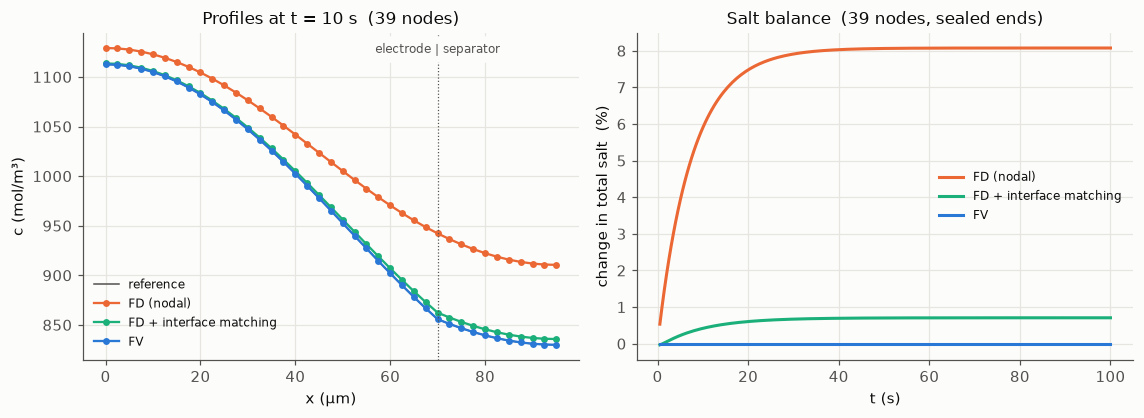

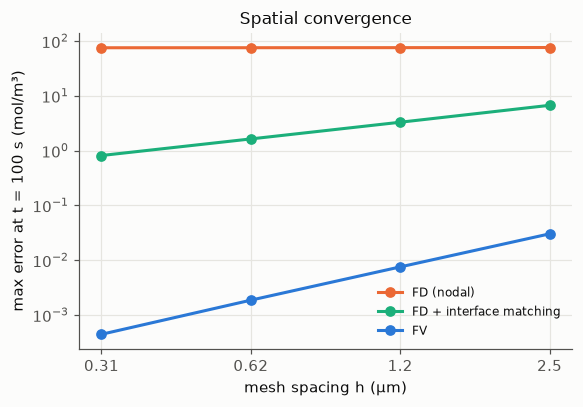

In [6]:
colors = dict(zip(methods, [ORANGE, AQUA, BLUE]))
t_snap, nj_show = 10.0, 39
x_show = uniform_mesh(nj_show)
_, snap_ref = simulate("FV", x_ref, snapshot_at=t_snap)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.9))
ax1.plot(x_ref * 1e6, snap_ref, color=INK2, linewidth=1, label="reference")
t_axis = dt * np.arange(1, int(round(t_end / dt)) + 1)
for m in methods:
    hist = []
    _, snap = simulate(m, x_show, snapshot_at=t_snap, history=hist)
    ax1.plot(x_show * 1e6, snap, "o-", color=colors[m], markersize=3.5, linewidth=1.5, label=m)
    ax2.plot(t_axis, 100 * (np.array(hist) / amount(x_show, c_init(x_show)) - 1), color=colors[m], label=m)
for ax in (ax1,):
    ax.axvline(Le * 1e6, color=INK2, linewidth=0.8, linestyle=":")
    ax.annotate("electrode | separator", xy=(Le * 1e6, 0.97), xycoords=("data", "axes fraction"), va="top",
                ha="center", color=INK2, fontsize=8, backgroundcolor="#fcfcfb")
ax1.set_xlabel("x (µm)"); ax1.set_ylabel("c (mol/m³)")
ax1.set_title(f"Profiles at t = {t_snap:g} s  ({nj_show} nodes)"); ax1.legend(fontsize=8, loc="lower left")
ax2.set_xlabel("t (s)"); ax2.set_ylabel("change in total salt  (%)")
ax2.set_title(f"Salt balance  ({nj_show} nodes, sealed ends)"); ax2.legend(fontsize=8, loc="center right")
fig.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(5.4, 3.8))
for m in methods:
    hs = [L / (nj - 1) * 1e6 for nj, *_ in results[m]]
    ax.loglog(hs, [r[1] for r in results[m]], "o-", color=colors[m], label=m)
ax.set_xticks([L / (nj - 1) * 1e6 for nj in grids], [f"{L / (nj - 1) * 1e6:.2g}" for nj in grids]); ax.minorticks_off()
ax.set_xlabel("mesh spacing h (µm)"); ax.set_ylabel(f"max error at t = {t_end:g} s (mol/m³)")
ax.set_title("Spatial convergence"); ax.legend(fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

The three schemes behave very differently:

| scheme | spatial accuracy | salt balance |
|---|---|---|
| **FD (nodal)** | converges to the **wrong** solution: the error does not decrease with refinement | creates about 8 % extra salt |
| **FD + interface matching** | correct, but **first order** | error $\propto h$ that never reaches zero |
| **FV** | **second order** | conserved to round-off on every mesh |

The nodal FD result is the dangerous kind of error: it looks smooth and plausible, and it converges, just not to the right answer. Only a conservation check or a refinement study against a trusted solution reveals it.

## 5. When finite differences are perfectly fine

Where the coefficients are smooth, FD and FV are close relatives. For constant $D$ on a uniform mesh they are **identical**: the ghost-point Neumann boundary gives exactly the half-cell FV equation, $\tfrac h2\,\dot c_0 = D\,(c_1-c_0)/h$. The check below uses the separator material alone:

In [7]:
Le_saved, De_saved, eps_e_saved = Le, De, eps_e
Le, De, eps_e = 0.0, Ds, eps_s                 # temporarily: a single, uniform material
x = uniform_mesh(77)
diff = np.abs(simulate("FD (nodal)", x) - simulate("FV", x)).max()
print(f"single material: max |FD - FV| = {diff:.1e} mol/m^3  (identical up to round-off)")
Le, De, eps_e = Le_saved, De_saved, eps_e_saved

single material: max |FD - FV| = 4.5e-13 mol/m^3  (identical up to round-off)


FD also makes **high-order boundary closures** easy. A second-order one-sided derivative, $\partial_x c(0) \approx (-3c_0 + 4c_1 - c_2)/2h$, couples node 0 to node 2, and that is exactly what the $\mathsf X$ (and, at the far end, $\mathsf Y$) blocks are for. See `examples/xy_boundary.py`: there the one-sided closure raises the whole solution from first to second order.

## 6. Finite volumes on a non-uniform mesh

Real cell models cluster nodes where the solution changes character, such as interfaces and electrode surfaces. The FV fill above already accepts any mesh. Here we compare a uniform mesh with one whose nodes cluster toward the electrode/separator interface, where the solution has a kink, using the same number of nodes:

In [8]:
def graded_mesh(n_e, n_s):
    """Nodes cluster toward the interface from both sides; a node sits exactly on it."""
    s_e = np.linspace(0, 1, n_e + 1)
    s_s = np.linspace(0, 1, n_s + 1)[1:]
    return np.concatenate([Le * np.sin(0.5 * np.pi * s_e), Le + Ls * (1 - np.cos(0.5 * np.pi * s_s))])

for (n_e, n_s), (nj, err_uniform, *_) in zip([(28, 10), (56, 20)], results["FV"]):
    x = graded_mesh(n_e, n_s)
    assert x.size == nj
    c = simulate("FV", x)
    err = np.abs(c - np.interp(x, x_ref, c_ref)).max()
    drift = (amount(x, c) - amount(x, c_init(x))) / amount(x, c_init(x))
    print(f"{nj:3d} nodes: uniform max error {err_uniform:.2e} | graded (h {np.diff(x).min() * 1e6:.2f}-"
          f"{np.diff(x).max() * 1e6:.2f} µm) max error {err:.2e}  ->  {err_uniform / err:.0f}x smaller; "
          f"salt drift {drift:+.1e}")

 39 nodes: uniform max error 3.03e-02 | graded (h 0.11-3.92 µm) max error 7.92e-04  ->  38x smaller; salt drift +0.0e+00
 77 nodes: uniform max error 7.56e-03 | graded (h 0.03-1.96 µm) max error 1.54e-04  ->  49x smaller; salt drift +2.2e-16


With the same number of unknowns, putting the nodes where the solution needs them reduces the error by well over an order of magnitude, and salt is still conserved to round-off. (Refining the graded mesh much further would make the comparison meaningless, because the error would drop below the interpolation error of the reference solution itself, about $3\times10^{-5}$ mol/m³.) The solver call never changed: BAND only sees the $\mathsf A,\mathsf B,\mathsf D$ blocks.

## 7. Which should I use?

| situation | recommendation |
|---|---|
| conservation laws (mass, charge, energy) with material interfaces, porosity or tortuosity jumps: **battery cells** | **finite volumes**: conservation is exact, and interfaces and non-uniform meshes come for free |
| smooth coefficients, single region, simple geometry | either; FD is often quicker to write and gives identical equations |
| high-order boundary conditions (one-sided derivatives) | FD closures using the $\mathsf X,\mathsf Y$ blocks |
| FD at an interface anyway | use a flux-matching row (§2b) and expect first order; or switch to FV |

Whatever you choose, **check it**: a conservation diagnostic like `amount(x, c)` and a refinement study against a reference solution catch exactly the kind of silent error shown in §4. Also verify any hand-written Jacobian with `bs.check_jacobian`, as in the earlier notebooks.